In [ ]:
# needed if run on the cloud, e.g. jupyter lab
%pip install seaborn

In [12]:
import pandas as pd

# Load the CSV file
file_path = "./gxa_bulk_over_.5sec.txt"
df = pd.read_csv(file_path, sep=" ", names=['request_type', 'url', 'response_time', 'args'], header=None)

In [13]:
df_clean = df.dropna(subset=["response_time"])

In [14]:
# Compute mean and standard deviation grouped by request type
summary_stats = df_clean.groupby("request_type")["response_time"].agg(["mean", "std","min","max","median","count"]).reset_index()
summary_stats

,request_type,mean,std,min,max,median,count
0,/gxa/search,7.072037,6.823793,0.601,67.394,4.3640,7371
1,das,9.537637,4.477538,1.195,20.998,8.7280,350
2,expdata,13.861667,30.321303,0.706,75.738,1.7185,6
3,experiments,4.319235,12.928176,0.600,149.590,0.7020,255
4,experiments-content,11.686860,31.885761,0.622,178.930,2.0345,86
5,genes,27.183510,41.923065,0.600,885.068,12.1990,18205
6,genesets,17.731000,12.973995,8.557,26.905,17.7310,2
7,json,11.636752,25.906360,0.600,501.090,3.5455,12620
8,resources,1.368799,3.967185,0.600,140.837,0.7550,5105
9,species,1.665065,0.789538,0.616,4.236,1.6880,31


/var/folders/72/spftrq4x09s54k4sqf12w9gm0000gp/T/ipykernel_84221/843973938.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(data=df_clean, x="request_type", y="response_time", ax=ax, order=sorted_request_types, palette=palette)


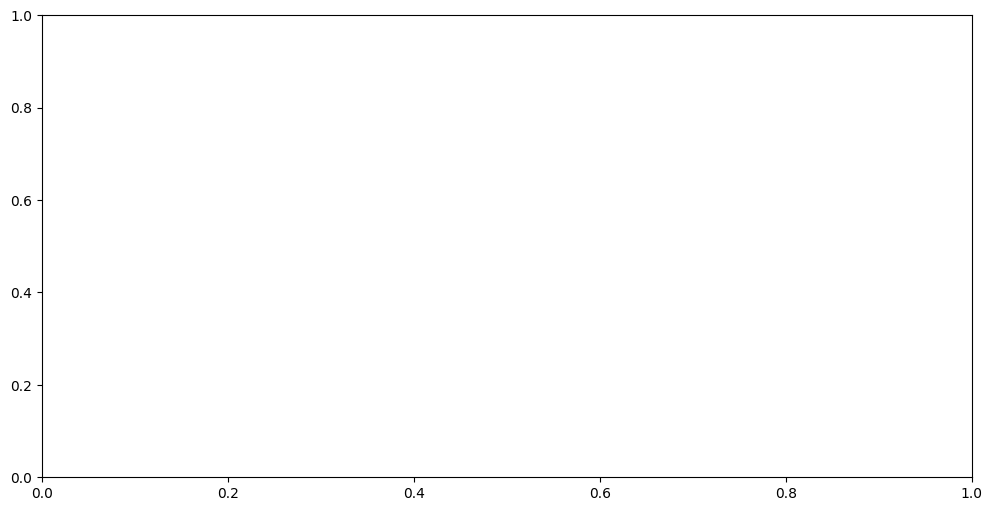

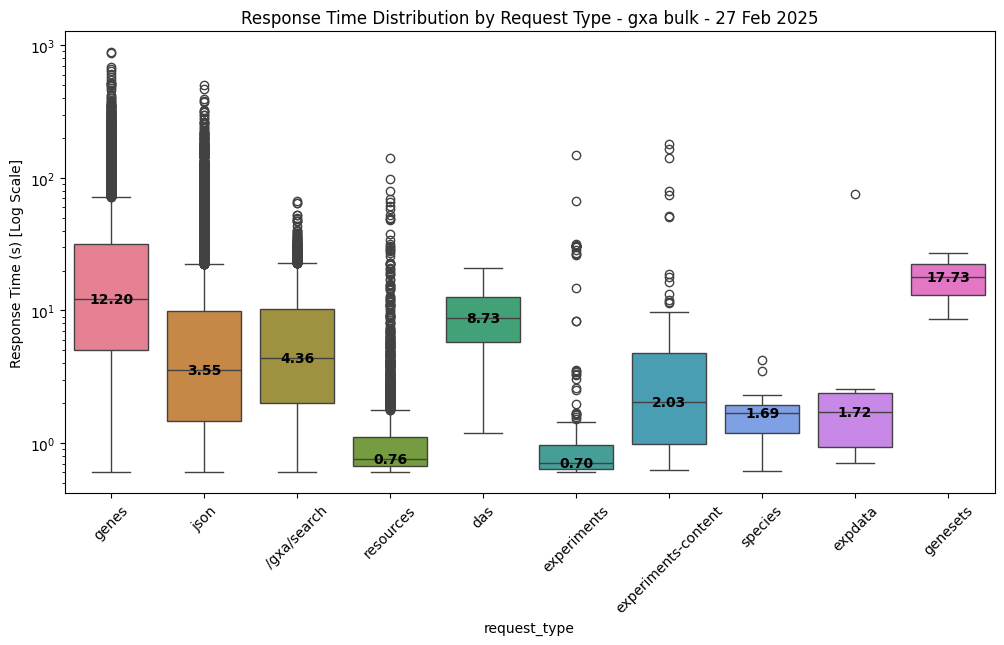

In [18]:


from matplotlib import pyplot as plt
import seaborn as sns

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))


# Ensure correct ordering of request types
sorted_request_types = df_clean["request_type"].value_counts().index
import matplotlib.patches as mpatches

# Define a color palette for different request types
palette = sns.color_palette("husl", n_colors=len(sorted_request_types))

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Create the boxplot with different colors
boxplot = sns.boxplot(data=df_clean, x="request_type", y="response_time", ax=ax, order=sorted_request_types, palette=palette)

# Set y-axis to log scale for better visualization
ax.set_yscale("log")
ax.set_ylabel("Response Time (s) [Log Scale]")
plt.title("Response Time Distribution by Request Type - gxa bulk - 27 Feb 2025")

# Calculate and add median labels correctly
medians = df_clean.groupby("request_type")["response_time"].median()
for i, req_type in enumerate(sorted_request_types):
    median_value = medians[req_type]
    ax.text(i, median_value, f"{median_value:.2f}", ha="center", va="center", 
            fontsize=10, color="black", fontweight="bold")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Show the plot
plt.show()
